<a href="https://colab.research.google.com/github/DigoShane/GitHub-ML/blob/main/simp_topology_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Topology optimization using the SIMP method

This numerical tour investigates the optimal design of an elastic structure through a topology optimization approach. It consists in finding the optimal distribution of a material in a computational domain which minimizes the compliance (or, equivalently, maximizes the stiffness) of the resulting structure under a fixed volume fraction constraint.

For instance, in the bottom animation, the optimal material density (a continuous field $\theta(x)\in[0;1]$) of a cantilever beam evolves with the topoology optimization algorithm iterations. The first 20 iterations correspond to a "non-penalized" distribution where intermediate densities (i.e. $0<\theta(x)<1$) are allowed. However, such a *gray-level* distribution is hard to realize in practice and one would like to obtain a *black-and-white* design of material/void distribution. This is what is achieved in the last iterations where some penalty is applied to intermediate densities, exhibiting finally a truss-like design. Note that the final design is not a global optimum but only a local one. Hence, different designs can well be obtained if changing the initial conditions or the mesh density for instance.

In [3]:
!wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh"
!bash "/tmp/fenics-install.sh"

--2026-05-21 15:14:39--  https://fem-on-colab.github.io/releases/fenics-install-release-real.sh
Resolving fem-on-colab.github.io (fem-on-colab.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to fem-on-colab.github.io (fem-on-colab.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4180 (4.1K) [application/x-sh]
Saving to: ‘/tmp/fenics-install.sh’

/tmp/fenics-install 100%[===================>]   4.08K  --.-KB/s    in 0s      

2026-05-21 15:14:39 (31.0 MB/s) - ‘/tmp/fenics-install.sh’ saved [4180/4180]

+ INSTALL_PREFIX=/usr/local
++ echo /usr/local
++ awk -F/ '{print NF-1}'
+ INSTALL_PREFIX_DEPTH=2
+ PROJECT_NAME=fem-on-colab
+ SHARE_PREFIX=/usr/local/share/fem-on-colab
+ FENICS_INSTALLED=/usr/local/share/fem-on-colab/fenics.installed
+ [[ ! -f /usr/local/share/fem-on-colab/fenics.installed ]]
+ set +x
























###############################################################################

In [4]:
%matplotlib inline
from dolfin import *
import matplotlib.pyplot as plt
import numpy as np

# Algorithmic parameters
niternp = 20 # number of non-penalized iterations
niter = 520 # total number of iterations
pmax = 4        # maximum SIMP exponent
exponent_update_frequency = 8 # minimum number of steps between exponent update
tol_mass = 1e-5 # tolerance on mass when finding Lagrange multiplier
thetamin = 0.001 # minimum density modeling void

In [5]:
# Problem parameters
thetamoy = 0.4 # target average material density
E = Constant(1)
nu = Constant(0.3)
lamda = E*nu/(1+nu)/(1-2*nu)
mu = E/(2*(1+nu))
f = Constant((0, -1)) # vertical downwards force

# Mesh
mesh = RectangleMesh(Point(-2, 0), Point(2, 1), 50, 30, "crossed")

#mesh size:
cell_sizes = np.array( [Cell(mesh, i).h() for i in range(mesh.num_cells())] )
# Min/max element size
hmin = np.min(cell_sizes)
hmax = np.max(cell_sizes)

print(f"Minimum element size = {hmin:.6e}")
print(f"Maximum element size = {hmax:.6e}")

# Boundaries
def left(x, on_boundary):
    return near(x[0], -2) and on_boundary
def load(x, on_boundary):
    return near(x[0], 2) and near(x[1], 0.5, 0.05)
facets = MeshFunction("size_t", mesh, 1)
AutoSubDomain(load).mark(facets, 1)
ds = Measure("ds", subdomain_data=facets)

# Function space for density field
V0 = FunctionSpace(mesh, "DG", 0)
# Function space for displacement
V2 = VectorFunctionSpace(mesh, "CG", 2)
# Fixed boundary condtions
bc = DirichletBC(V2, Constant((0, 0)), left)

p = Constant(1) # SIMP penalty exponent
exponent_counter = 0 # exponent update counter
lagrange = Constant(1) # Lagrange multiplier for volume constraint

thetaold = Function(V0, name="Density")
thetaold.interpolate(Constant(thetamoy))
coeff = thetaold**p
theta = Function(V0)

volume = assemble(Constant(1.)*dx(domain=mesh))
avg_density_0 = assemble(thetaold*dx)/volume # initial average density
avg_density = 0.

Minimum element size = 4.333333e-02
Maximum element size = 8.000000e-02
Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_cd40aaaf5bc0b68be1a587d7bb9a08da6d0820e7

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00583768 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.0269392 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representation
INFO:FFC:---------------------------

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_f4c31f6e8b0e7ddceb14ce599aa08d063c1bdf82

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00230837 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.71506 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representation

Calling FFC just-in-time (JIT) compiler, this may take some time.


...

Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling coordinate_mapping ffc_coordinate_mapping_84d495a78101e005b3c3473583b2e920e2771158

INFO:FFC:Compiler stage 1: Analyzing coordinate_mapping(s)
INFO:FFC:-------------------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00313115 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 0 elements
INFO:FFC:  Computing representation of 0 dofmaps
INFO:FFC:  Computing representation of 1 coordinate mappings
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.0128365 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representation
INFO:FFC:--------------------------------------------------------
INFO

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_c711cbf1eb43fc4ee65c45a3c53363a0248cfe9c

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      0
  Arguments:                 '()'
  Number of coefficients:    1
  Coefficients:              '[Density]'
  Unique elements:           'DG0(?,?), Vector<2 x CG1(?,?)>'
  Unique sub elements:       'DG0(?,?), Vector<2 x CG1(?,?)>, CG1(?,?)'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 0
INFO:FFC:  quadrature_degree: 0
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.0155678 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:--------------------

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_422555fab3d4ddd5bedc15825581359968b5b77a

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00216985 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.0108433 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representati

In [6]:
def eps(v):
    return sym(grad(v))
def sigma(v):
    return coeff*(lamda*div(v)*Identity(2)+2*mu*eps(v))
def energy_density(u, v):
    return inner(sigma(u), eps(v))

# Inhomogeneous elastic variational problem
u_ = TestFunction(V2)
du = TrialFunction(V2)
a = inner(sigma(u_), eps(du))*dx
L = dot(f, u_)*ds(1)

In [7]:
#projection onto DG space.
#https://comet-fenics.readthedocs.io/en/latest/tips_and_tricks.html
def local_project(v, V):
    dv = TrialFunction(V)
    v_ = TestFunction(V)
    a_proj = inner(dv, v_)*dx
    b_proj = inner(v, v_)*dx
    solver = LocalSolver(a_proj, b_proj)
    solver.factorize()
    u = Function(V)
    solver.solve_local_rhs(u)
    return u
def update_theta():
    theta.assign(local_project((p*coeff*energy_density(u, u)/lagrange)**(1/(p+1)), V0))
    thetav = theta.vector().get_local()
    theta.vector().set_local(np.maximum(np.minimum(1, thetav), thetamin))# enforces θmin​≤ θ ≤1
    theta.vector().apply("insert")
    avg_density = assemble(theta*dx)/volume
    return avg_density

In [8]:
# def update_lagrange_multiplier(avg_density):
#     avg_density1 = avg_density
#     # Initial bracketing of Lagrange multiplier
#     if (avg_density1 < avg_density_0):
#         lagmin = float(lagrange)
#         while (avg_density < avg_density_0):
#             lagrange.assign(Constant(lagrange/2))
#             avg_density = update_theta()
#         lagmax = float(lagrange)
#     elif (avg_density1 > avg_density_0):
#         lagmax = float(lagrange)
#         while (avg_density > avg_density_0):
#             lagrange.assign(Constant(lagrange*2))
#             avg_density = update_theta()
#         lagmin = float(lagrange)
#     else:
#         lagmin = float(lagrange)
#         lagmax = float(lagrange)

#     # Dichotomy on Lagrange multiplier
#     inddico=0
#     while ((abs(1.-avg_density/avg_density_0)) > tol_mass):
#         lagrange.assign(Constant((lagmax+lagmin)/2))
#         avg_density = update_theta()
#         inddico += 1;
#         if (avg_density < avg_density_0):
#             lagmin = float(lagrange)
#         else:
#             lagmax = float(lagrange)
#     print("   Dichotomy iterations:", inddico)

def update_lagrange_multiplier(avg_density):

    target_density = avg_density_0
    current_lambda = float(lagrange)

    if avg_density < target_density:
        lambda_upper = current_lambda
        while avg_density < target_density:
            current_lambda /= 2.0
            lagrange.assign(Constant(current_lambda))
            avg_density = update_theta()
        lambda_lower = current_lambda

    elif avg_density > target_density:
        lambda_lower = current_lambda
        while avg_density > target_density:
            current_lambda *= 2.0
            lagrange.assign(Constant(current_lambda))
            avg_density = update_theta()
        lambda_upper = current_lambda

    else:

        lambda_lower = current_lambda
        lambda_upper = current_lambda

    inddico = 0

    while abs(1.0 - avg_density/target_density) > tol_mass:
        lambda_mid = 0.5*(lambda_lower + lambda_upper)
        lagrange.assign(Constant(lambda_mid))
        avg_density = update_theta()
        inddico += 1
        if avg_density < target_density:
            lambda_upper = lambda_mid
        else:
            lambda_lower = lambda_mid
    print("   Dichotomy iterations:", inddico)

In [9]:
def update_exponent(exponent_counter):
    exponent_counter += 1
    if (i < niternp):
        p.assign(Constant(1))
    elif (i >= niternp):
        if i == niternp:
            print("\n Starting penalized iterations\n")
        # If you are above freq update of counter and compliance change is less
        # The algorithm wants to increase p ONLY when the topology has stabilized somewhat.
        # If compliance is still changing rapidly --- topology still evolving, pptimizer not yet settled.
        # So increasing penalization too early would be dangerous.
        if ((abs(compliance-old_compliance) < 0.01*compliance_history[0]) and
            (exponent_counter > exponent_update_frequency) ):
            # average gray level
            gray_level = assemble((theta-thetamin)*(1.-theta)*dx)*4/volume
            p.assign(Constant(min(float(p)*(1+0.3**(1.+gray_level/2)), pmax)))
            exponent_counter = 0
            print("   Updated SIMP exponent p = ", float(p))
    return exponent_counter


In [10]:
u = Function(V2, name="Displacement")
old_compliance = 1e30

ffile = XDMFFile("topology_optimization.xdmf")
ffile.parameters["flush_output"] = True
ffile.parameters["functions_share_mesh"] = True

compliance_history = []
density_tol = 1e-3

for i in range(niter):
    solve( a == L, u, bc, solver_parameters={"linear_solver": "cg", "preconditioner": "hypre_amg"} )

    ffile.write(thetaold, i)
    ffile.write(u, i)

    compliance = assemble(action(L, u))
    compliance_history.append(compliance)
    print( "Iteration {}: compliance =".format(i), compliance)

    avg_density = update_theta()
    update_lagrange_multiplier(avg_density)
    exponent_counter = update_exponent( exponent_counter )

    density_change = np.max( np.abs( theta.vector().get_local() - thetaold.vector().get_local()))
    print("Max density change =", density_change)

    if ( i > niternp and density_change < density_tol and float(p) >= pmax ):
        print("\nTopology converged.\n")
        break

    thetaold.assign(theta)
    old_compliance = compliance

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_d41f70c3f1ac4d5a48d48c7706406a2cc5a5fc83

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:FFC:  
INFO:FFC:  Geometric dimension:                 2
  Number of exterior_facet subdomains: 2
  Rank:                                1
  Arguments:                           '(v_0)'
  Number of coefficients:              1
  Coefficients:                        '[f_2]'
  Unique elements:                     'Vector<2 x CG2(?,?)>, Vector<2 x R0(?,?)>, V
                                       ector<2 x CG1(?,?)>'
  Unique sub elements:                 'Vector<2 x CG2(?,?)>, Vector<2 x R0(?,?)>, 

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling element ffc_element_17d5bd7e022a45e71c9f390bd00f3f09885a1fd0

INFO:FFC:Compiler stage 1: Analyzing element(s)
INFO:FFC:--------------------------------------
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.00285769 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:-------------------------------------------------------
INFO:FFC:  Computing representation of 1 elements
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 1 dofmaps
DEBUG:FFC:  Reusing element from cache
INFO:FFC:  Computing representation of 0 coordinate mappings
INFO:FFC:  Computing representation of integrals
INFO:FFC:  Computing representation of forms
INFO:FFC:  
INFO:FFC:Compiler stage 2 finished in 0.0104127 seconds.

INFO:FFC:Compiler stage 3: Optimizing intermediate representati

Calling FFC just-in-time (JIT) compiler, this may take some time.


...

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_690a9f014311e8a3034242ce6456b0a288d01dee

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      1
  Arguments:                 '(v_0)'
  Number of coefficients:    6
  Coefficients:              '[f_0, f_1, f_14, f_15, Density, Displacement]'
  Unique elements:           'DG0(?,?), R0(?,?), Vector<2 x CG2(?,?)>, Vector<2 x CG
                             1(?,?)>'
  Unique sub elements:       'DG0(?,?), R0(?,?), Vector<2 x CG2(?

   Dichotomy iterations: 14
Max density change = 0.6
Iteration 1: compliance = 1.6679851829524828
   Dichotomy iterations: 13
Max density change = 0.33885806682555975
Iteration 2: compliance = 1.5834161623471825
   Dichotomy iterations: 13
Max density change = 0.2131735174546321
Iteration 3: compliance = 1.5652393385785828
   Dichotomy iterations: 11
Max density change = 0.14445738852334966
Iteration 4: compliance = 1.559011017771446
   Dichotomy iterations: 12
Max density change = 0.0953742027941753
Iteration 5: compliance = 1.5561378231251057
   Dichotomy iterations: 13
Max density change = 0.07050244650159654
Iteration 6: compliance = 1.554545645462085
   Dichotomy iterations: 12
Max density change = 0.05967574170912415
Iteration 7: compliance = 1.5535800257264891
   Dichotomy iterations: 13
Max density change = 0.048408237328688486
Iteration 8: compliance = 1.5529313907236344
   Dichotomy iterations: 11
Max density change = 0.0388563235143663
Iteration 9: compliance = 1.55248970665

Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_b7e79db44bba02de81b5eb76e185d6ad0a6a79a3

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      0
  Arguments:                 '()'
  Number of coefficients:    1
  Coefficients:              '[f_20]'
  Unique elements:           'DG0(?,?), Vector<2 x CG1(?,?)>'
  Unique sub elements:       'DG0(?,?), Vector<2 x CG1(?,?)>, CG1(?,?)'
  
INFO:FFC:  representation:    auto --> uflacs
INFO:FFC:  quadrature_rule:   auto --> default
INFO:FFC:  quadrature_degree: auto --> 0
INFO:FFC:  quadrature_degree: 0
INFO:FFC:  
INFO:FFC:Compiler stage 1 finished in 0.015722 seconds.

INFO:FFC:Compiler stage 2: Computing intermediate representation
INFO:FFC:------------------------

   Updated SIMP exponent p =  1.2256897987073871
Max density change = 0.00843235443909196
Iteration 21: compliance = 1.6948138187292519
   Dichotomy iterations: 13
Max density change = 0.18751143564773654
Iteration 22: compliance = 1.6883781202893586
   Dichotomy iterations: 12
Max density change = 0.13424773662066247
Iteration 23: compliance = 1.6863497876055282
   Dichotomy iterations: 12
Max density change = 0.10594670330630895
Iteration 24: compliance = 1.6850951012311741
   Dichotomy iterations: 11
Max density change = 0.08776350614424139
Iteration 25: compliance = 1.684137219622639
   Dichotomy iterations: 13
Max density change = 0.07315519567621365
Iteration 26: compliance = 1.6833105983968761
   Dichotomy iterations: 12
Max density change = 0.06183346504401144
Iteration 27: compliance = 1.6825900986530462
   Dichotomy iterations: 12
Max density change = 0.05271551496068039
Iteration 28: compliance = 1.6819047589204956
   Dichotomy iterations: 11
Max density change = 0.045197599

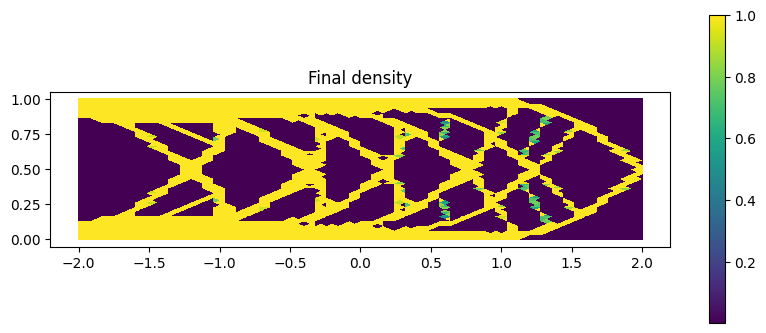

In [16]:
# plot(theta, cmap="bone_r")
# plt.title("Final density")
# plt.show();

# plt.figure()
# plt.plot(np.arange(1, niter+1), compliance_history)
# ax = plt.gca()
# ymax = ax.get_ylim()[1]
# plt.plot([niternp, niternp], [0, ymax], "--k")
# plt.annotate(r"$\leftarrow$ Penalized iterations $\rightarrow$", xy=[niternp+1, ymax*0.02], fontsize=14)
# plt.xlabel("Number of iterations")
# plt.ylabel("Compliance")
# plt.title("Convergence history", fontsize=16)
# plt.show();

plt.figure(figsize=(10,4))

c = plot(theta)
plt.colorbar(c)

plt.title("Final density")
plt.show()

## References

[ALL07]: Allaire, Grégoire, and Marc Schoenauer. *Conception optimale de structures.* Vol. 58. Berlin: Springer, 2007.

[BEN03]: Bendsoe, Martin Philip and Sigmund, Ole. *Topology Optimization: Theory, Methods, and Applications*. Springer Science & Business Media, 2003.

In [12]:
from google.colab import files

files.download("topology_optimization.xdmf")
files.download("topology_optimization.h5")

# Please open using Paraview and hit play at the top.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
stress = sigma(u)

Vsig = FunctionSpace(mesh, "CG", 1)

#exact components:
sigma_xx = project(stress[0,0], Vsig)
sigma_yy = project(stress[1,1], Vsig)
sigma_xy = project(stress[0,1], Vsig)

#principal stresses:
s_avg = 0.5*(stress[0,0] + stress[1,1])
R = sqrt( ((stress[0,0] - stress[1,1])/2)**2 + stress[0,1]**2 )
sigma_1 = project(s_avg + R, Vsig)
sigma_2 = project(s_avg - R, Vsig)

#von mises
von_Mises = project( sqrt( stress[0,0]**2 - stress[0,0]*stress[1,1] + stress[1,1]**2 + 3*stress[0,1]**2 ), Vsig )

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_bea8d253b08e57e9bebffb6d46586be9369516ff

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      1
  Arguments:                 '(v_0)'
  Number of coefficients:    5
  Coefficients:              '[f_0, f_1, f_14, Density, Displacement]'
  Unique elements:           'CG1(?,?), R0(?,?), DG0(?,?), Vector<2 x CG2(?,?)>, Vec
                             tor<2 x CG1(?,?)>'
  Unique sub elements:       'CG1(?,?), R0(?,?), DG0(?,?), Vector<2 x CG2(?,?)>, Vec
                             tor<2 x

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_0a8ba9e915537d9229b908884265074075cb7b65

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      1
  Arguments:                 '(v_0)'
  Number of coefficients:    5
  Coefficients:              '[f_0, f_1, f_14, Density, Displacement]'
  Unique elements:           'CG1(?,?), R0(?,?), DG0(?,?), Vector<2 x CG2(?,?)>, Vec
                             tor<2 x CG1(?,?)>'
  Unique sub elements:       'CG1(?,?), R0(?,?), DG0(?,?), Vector<2 x CG2(?,?)>, Vec
                             tor<2 x

Calling FFC just-in-time (JIT) compiler, this may take some time.


...

Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_215575b2052d2102eecdfc8731c5fa73cc9f2276

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      1
  Arguments:                 '(v_0)'
  Number of coefficients:    5
  Coefficients:              '[f_0, f_1, f_14, Density, Displacement]'
  Unique elements:           'CG1(?,?), R0(?,?), DG0(?,?), Vector<2 x CG2(?,?)>, Vec
                             tor<2 x CG1(?,?)>'
  Unique sub elements:       'CG1(?,?), R0(?,?), DG0(?,?), Vector<2 x CG2(?,?)>, Vec
                             tor<2 x

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_e8b4e1f5b0e3e56f7fc18d5084e213677dc51890

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      1
  Arguments:                 '(v_0)'
  Number of coefficients:    5
  Coefficients:              '[f_0, f_1, f_14, Density, Displacement]'
  Unique elements:           'CG1(?,?), R0(?,?), DG0(?,?), Vector<2 x CG2(?,?)>, Vec
                             tor<2 x CG1(?,?)>'
  Unique sub elements:       'CG1(?,?), R0(?,?), DG0(?,?), Vector<2 x CG2(?,?)>, Vec
                             tor<2 x

Calling FFC just-in-time (JIT) compiler, this may take some time.


Level 25:FFC:Calling FFC just-in-time (JIT) compiler, this may take some time.
INFO:FFC:Compiling form ffc_form_890de18b0c54b23ca76e76db5ab6e43814701392

INFO:FFC:Compiler stage 1: Analyzing form(s)
INFO:FFC:-----------------------------------
DEBUG:FFC:  Preprocessing form using 'uflacs' representation family.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:UFL_LEGACY:Adjusting missing element cell to triangle.
INFO:FFC:  
INFO:FFC:  Geometric dimension:       2
  Number of cell subdomains: 0
  Rank:                      1
  Arguments:                 '(v_0)'
  Number of coefficients:    5
  Coefficients:              '[f_0, f_1, f_14, Density, Displacement]'
  Unique elements:           'CG1(?,?), R0(?,?), DG0(?,?), Vector<2 x CG2(?,?)>, Vec
                             tor<2 x CG1(?,?)>'
  Unique sub elements:       'CG1(?,?), R0(?,?), DG0(?,?), Vector<2 x CG2(?,?)>, Vec
                             tor<2 x

In [31]:
#project soln:
density = project(thetaold, Vsig)

def compute_material_extrema(field, density, threshold=0.05):
    field_array = field.vector().get_local()
    density_array = density.vector().get_local()
    material_values = field_array[density_array > threshold]
    return np.min(material_values), np.max(material_values)

def masked_copy(field, density, void_value, threshold=0.05):
    masked = Function(field.function_space())
    field_array = field.vector().get_local()
    density_array = density.vector().get_local()
    masked_array = field_array.copy()

    #set void value
    masked_array[density_array < threshold] = np.nan #void_value
    masked.vector().set_local(masked_array)
    masked.vector().apply("insert")
    return masked

#colorbar fix for each plot
def plot_field(field, density, title, vmin, vmax, void_value, threshold=0.05):
    masked_field = masked_copy(field, density, void_value, threshold)
    plt.figure(figsize=(10,4))
    p = plot(masked_field)
    p.set_array(np.ma.masked_invalid( p.get_array()))
    p.set_clim(vmin, vmax)
    plt.colorbar(p)
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

#determine extrema for each
sigma_xx_min, sigma_xx_max = compute_material_extrema( sigma_xx, density )
sigma_yy_min, sigma_yy_max = compute_material_extrema( sigma_yy, density )
sigma_xy_min, sigma_xy_max = compute_material_extrema( sigma_xy, density )
sigma_1_min, sigma_1_max = compute_material_extrema( sigma_1, density )
sigma_2_min, sigma_2_max = compute_material_extrema( sigma_2, density)
vm_min, vm_max = compute_material_extrema( von_Mises, density )

#priniting the max and min stresses
print("\nStress extrema over material region:\n")
print(f"sigma_xx : min = {sigma_xx_min:.6e}, "
      f"max = {sigma_xx_max:.6e}")
print(f"sigma_yy : min = {sigma_yy_min:.6e}, "
      f"max = {sigma_yy_max:.6e}")
print(f"sigma_xy : min = {sigma_xy_min:.6e}, "
      f"max = {sigma_xy_max:.6e}")
print(f"sigma_1  : min = {sigma_1_min:.6e}, "
      f"max = {sigma_1_max:.6e}")
print(f"sigma_2  : min = {sigma_2_min:.6e}, "
      f"max = {sigma_2_max:.6e}")
print(f"von Mises: min = {vm_min:.6e}, "
      f"max = {vm_max:.6e}")

print("\nFinal compliance =", compliance)


Stress extrema over material region:

sigma_xx : min = -4.029673e+00, max = 4.029676e+00
sigma_yy : min = -6.706368e+00, max = 6.706577e+00
sigma_xy : min = -2.360488e+00, max = 7.312086e-01
sigma_1  : min = -2.760935e+00, max = 6.922424e+00
sigma_2  : min = -6.922127e+00, max = 2.760919e+00
von Mises: min = -7.086943e-01, max = 6.382619e+00

Final compliance = 1.9084587960199153


ValueError: z array must not contain non-finite values within the triangulation

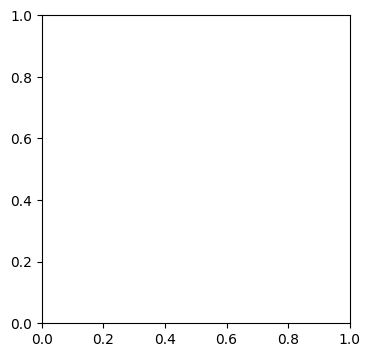

In [34]:
#plotting the masked fields:
plot_field( sigma_xx, density, r"$\sigma_{xx}$", sigma_xx_min, sigma_xx_max)
plot_field( sigma_yy, density, r"$\sigma_{yy}$", sigma_yy_min, sigma_yy_max)
plot_field( sigma_xy, density, r"$\sigma_{xy}$", sigma_xy_min, sigma_xy_max)
plot_field( sigma_1, density, r"Principal stress $\sigma_1$", sigma_1_min, sigma_1_max)
plot_field( sigma_2, density, r"Principal stress $\sigma_2$", sigma_2_min, sigma_2_max)
plot_field( von_Mises, density, r"von Mises stress", vm_min, vm_max)